# Trader Behavior and Performance Analysis Using Market Sentiment
**Objective:**
The goal of this analysis is to examine how market sentiment (Fear and Greed Index) influences trader behavior and trading performance. By combining trader transaction data with market sentiment data, we analyze key metrics such as profitability (PnL), win rate, drawdown, trade frequency, position size, and long/short bias.

In [102]:
import pandas as pd
import matplotlib.pyplot as plt

In [103]:
Sentiment= pd.read_csv("fear_greed_index.csv")
Trader= pd.read_csv("historical_data.csv")

In [104]:

Sentiment["date"]=pd.to_datetime(Sentiment["date"])
Sentiment.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   timestamp       2644 non-null   int64         
 1   value           2644 non-null   int64         
 2   classification  2644 non-null   object        
 3   date            2644 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 82.8+ KB


In [105]:
Trader["date"]= pd.to_datetime(Trader["Timestamp IST"], format="%d-%m-%Y %H:%M").dt.date
Trader["date"]= pd.to_datetime(Trader["date"])

Trader.info()
Trader.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89709 entries, 0 to 89708
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Account           89709 non-null  object        
 1   Coin              89709 non-null  object        
 2   Execution Price   89709 non-null  float64       
 3   Size Tokens       89709 non-null  float64       
 4   Size USD          89709 non-null  float64       
 5   Side              89709 non-null  object        
 6   Timestamp IST     89709 non-null  object        
 7   Start Position    89709 non-null  float64       
 8   Direction         89709 non-null  object        
 9   Closed PnL        89709 non-null  float64       
 10  Transaction Hash  89709 non-null  object        
 11  Order ID          89709 non-null  int64         
 12  Crossed           89709 non-null  bool          
 13  Fee               89709 non-null  float64       
 14  Trade ID          8970

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02


In [106]:
market_sentiment = pd.merge(Sentiment,Trader,how="left",on="date")

market_sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91881 entries, 0 to 91880
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   timestamp         91881 non-null  int64         
 1   value             91881 non-null  int64         
 2   classification    91881 non-null  object        
 3   date              91881 non-null  datetime64[ns]
 4   Account           89703 non-null  object        
 5   Coin              89703 non-null  object        
 6   Execution Price   89703 non-null  float64       
 7   Size Tokens       89703 non-null  float64       
 8   Size USD          89703 non-null  float64       
 9   Side              89703 non-null  object        
 10  Timestamp IST     89703 non-null  object        
 11  Start Position    89703 non-null  float64       
 12  Direction         89703 non-null  object        
 13  Closed PnL        89703 non-null  float64       
 14  Transaction Hash  8970

In [107]:
#Rows Before cleaning
market_sentiment.shape

(91881, 20)

In [108]:
market_sentiment.dropna(inplace=True)

market_sentiment.isnull().sum()



timestamp           0
value               0
classification      0
date                0
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [109]:

market_sentiment.duplicated().sum()

np.int64(0)

In [110]:
#Rows After Cleaning
market_sentiment.shape

(89703, 20)

## key Metrics

In [111]:
# Daily Pnl

Daily_Pnl = market_sentiment.groupby(["date","Account"])["Closed PnL"].sum().reset_index()
print(Daily_Pnl.head())

        date                                     Account  Closed PnL
0 2023-05-01  0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891    0.000000
1 2023-12-05  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    0.000000
2 2023-12-14  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23 -205.434737
3 2023-12-15  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23  -24.632034
4 2023-12-16  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    0.000000


In [112]:
# Win Rate 

Win_rate = (market_sentiment["Closed PnL"]>0).mean()*100
print(Win_rate)

44.65736931875188


In [113]:
# Average trade size

Trade_size = (market_sentiment["Size USD"]).mean()
print(Trade_size)

9040.815429807253


In [114]:
#Trades per Day

Trades_per_day = market_sentiment.groupby("date").size()
print(Trades_per_day)

date
2023-05-01       3
2023-12-05       9
2023-12-14      11
2023-12-15       2
2023-12-16       3
              ... 
2025-04-27     163
2025-04-28     697
2025-04-29    1047
2025-04-30     601
2025-05-01     667
Length: 466, dtype: int64


In [115]:
# Long vs Short Ratio

side_counts = market_sentiment["Side"].value_counts()
print(side_counts)

Side
SELL    45105
BUY     44598
Name: count, dtype: int64


In [116]:
long_short_ratio = side_counts["BUY"] / side_counts["SELL"]

print(f"Long : Short = {round(long_short_ratio,2)} : 1")

Long : Short = 0.99 : 1


In [117]:
#Leverage Distribution

market_sentiment["Start Position"].describe()

count    8.970300e+04
mean     2.960777e+04
std      4.916323e+05
min     -1.433463e+07
25%     -4.438100e-01
50%      4.901500e+02
75%      2.935683e+04
max      3.050948e+07
Name: Start Position, dtype: float64

In [118]:

pnl = market_sentiment.groupby("classification")["Closed PnL"].mean()

market_sentiment["profit_trade"] = market_sentiment["Closed PnL"] > 0
win_rate = market_sentiment.groupby("classification")["profit_trade"].mean()*100

drawdown = market_sentiment.groupby("classification")["Closed PnL"].min()

In [119]:
performance_table = pd.DataFrame({"PnL": pnl,"Win Rate": win_rate,"Drawdown Proxy": drawdown})

print(performance_table)

                       PnL   Win Rate  Drawdown Proxy
classification                                       
Extreme Fear     76.680902  37.067922    -29370.11980
Extreme Greed   121.280163  50.977936    -10259.46800
Fear             81.494516  45.973526    -19841.24014
Greed            74.148885  39.717212   -117990.10410
Neutral          71.859323  46.565460    -18993.46842


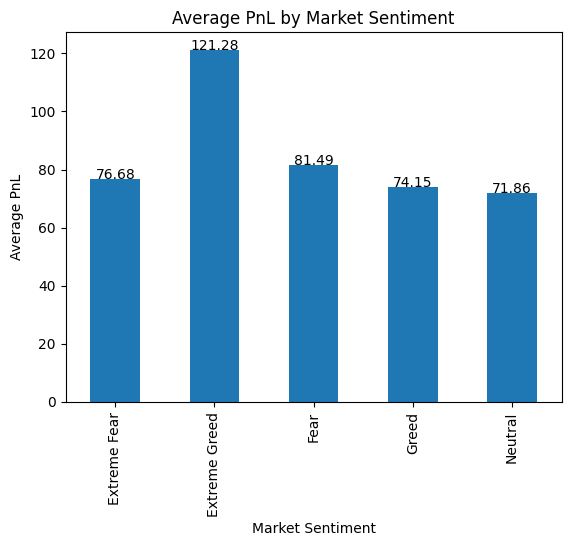

In [120]:
pnl.plot(kind="bar")
plt.title("Average PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average PnL")
for i, v in enumerate(pnl):
    plt.text(i, v, round(v,2), ha='center')
plt.show()

### Insight
The chart shows that average PnL varies across different market sentiment conditions. Traders achieve the highest profitability during Extreme Greed (~121), which is approximately 59% higher than Extreme Fear (~76) and around 70% higher than Neutral (~71). During Fear (~81), profitability remains moderate, about 13% higher than Neutral sentiment. This suggests that traders tend to perform better during strong bullish market conditions, while profits are relatively lower when the market sentiment is neutral or uncertain.

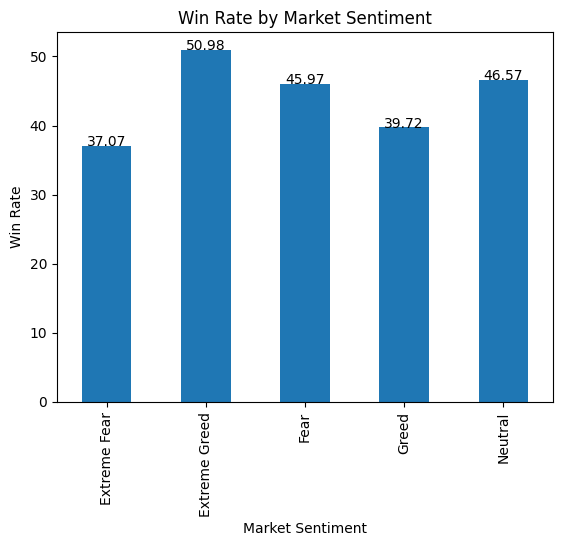

In [121]:
win_rate.plot(kind="bar")
plt.title("Win Rate by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Win Rate")
for i, v in enumerate(win_rate):
    plt.text(i, v, round(v,2), ha='center')
plt.show()

### Insight
The win rate varies across different market sentiment conditions. Traders achieve the highest win rate during Extreme Greed (~50.98%), indicating that bullish market conditions provide better trading opportunities. In contrast, the lowest win rate occurs during Extreme Fear (~37.07%), suggesting that high market uncertainty reduces successful trades. Fear (~45.97%) and Neutral (~46.57%) show moderate win rates, while Greed (~39.72%) indicates slightly lower trading success compared to other conditions.

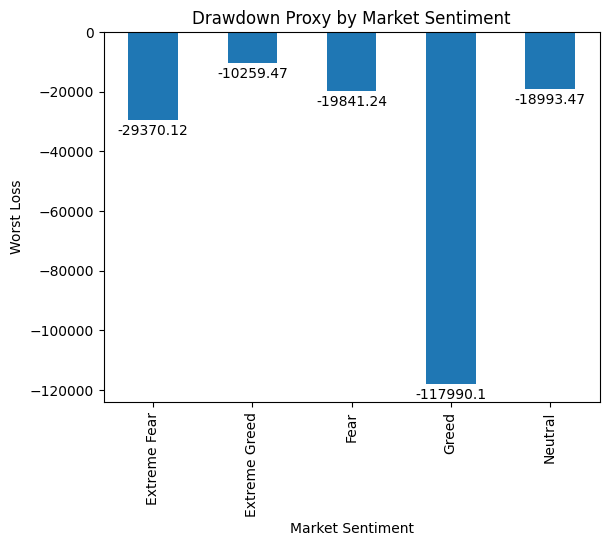

In [122]:
drawdown.plot(kind="bar")
plt.title("Drawdown Proxy by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Worst Loss")
for i, v in enumerate(drawdown):
    plt.text(i, v - 5000, round(v,2), ha='center')
plt.show()

### Insight
The drawdown proxy shows that traders experience the largest losses during Greed sentiment (~-117,990), indicating that excessive optimism in the market may lead traders to take higher risks and larger positions. In comparison, Extreme Greed (~-10,259) shows significantly smaller losses, suggesting more controlled trading behavior. Fear (-29,370) and Neutral (-18,993) show moderate drawdowns, while Fear conditions still expose traders to noticeable downside risk. Overall, this indicates that traders may become overconfident during Greed phases, increasing the potential for large losses.

In [123]:
trade_frequency = market_sentiment.groupby("classification").size()
print(trade_frequency)

classification
Extreme Fear      7435
Extreme Greed    14367
Fear             30672
Greed            21288
Neutral          15941
dtype: int64


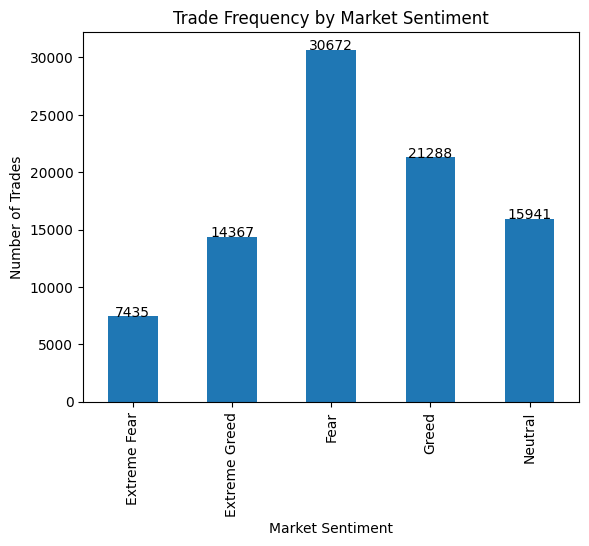

In [124]:
trade_frequency.plot(kind="bar")

plt.title("Trade Frequency by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")

for i, v in enumerate(trade_frequency):
    plt.text(i, v, str(v), ha="center")

plt.show()

### Insight
The trade frequency varies across different market sentiment conditions. The highest number of trades occurs during Fear (~30,672 trades), indicating that traders are more active when the market is uncertain or volatile. Greed (~21,288 trades) and Neutral (~15,941 trades) show moderate trading activity. In contrast, Extreme Fear (~7,435 trades) has the lowest trading frequency, suggesting that traders may reduce participation during periods of high market panic. Overall, this indicates that traders tend to increase trading activity when market uncertainty creates more trading opportunities.

In [125]:
position_size = market_sentiment.groupby("classification")["Start Position"].mean()
print(position_size)


classification
Extreme Fear     21605.395702
Extreme Greed    28172.567696
Fear             32342.536279
Greed            13686.867053
Neutral          50632.818554
Name: Start Position, dtype: float64


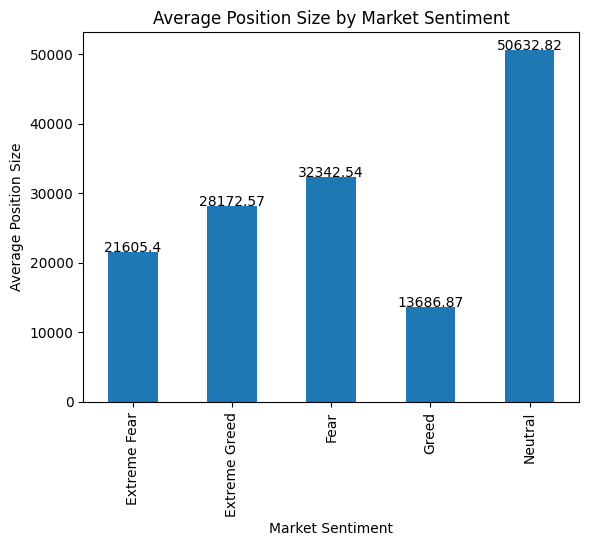

In [126]:
position_size.plot(kind="bar")

plt.title("Average Position Size by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Position Size")

for i, v in enumerate(position_size):
    plt.text(i, v, round(v,2), ha="center")

plt.show()


### Insight
The average position size varies across different market sentiment conditions. The largest average position size occurs during Neutral sentiment (~50,633), indicating that traders take larger exposure when the market direction is unclear. Fear (~32,343) and Extreme Greed (~28,173) also show relatively high position sizes, suggesting moderate risk-taking behavior. In contrast, Greed (~13,687) has the smallest average position size, which may indicate more cautious trading during optimistic market conditions. Overall, this suggests that trader risk exposure changes depending on market sentiment.

In [127]:
long_short = market_sentiment.groupby(["classification","Side"]).size().unstack()
print(long_short)

Side              BUY   SELL
classification              
Extreme Fear     4239   3196
Extreme Greed    6761   7606
Fear            15121  15551
Greed           10284  11004
Neutral          8193   7748


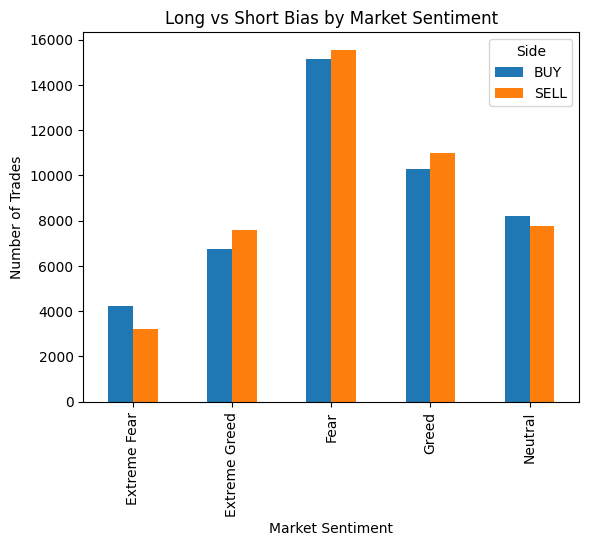

In [128]:
long_short.plot(kind="bar")

plt.title("Long vs Short Bias by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")

plt.show()

### Insight
The chart shows the distribution of long (BUY) and short (SELL) trades across different market sentiment conditions. During Fear and Greed, the number of SELL trades is slightly higher than BUY trades, suggesting that traders may expect possible price declines or hedge their positions. In Extreme Fear, BUY trades are higher than SELL trades, indicating that some traders attempt to buy assets at lower prices during market panic. Overall, the difference between long and short positions is relatively small, showing that traders maintain a fairly balanced trading strategy across market sentiment phases.

In [129]:
trade_size = market_sentiment.groupby("classification")["Size USD"].mean()
print(trade_size)

classification
Extreme Fear      5266.810243
Extreme Greed     5916.956226
Fear             10796.524210
Greed            10708.051726
Neutral           8011.832792
Name: Size USD, dtype: float64


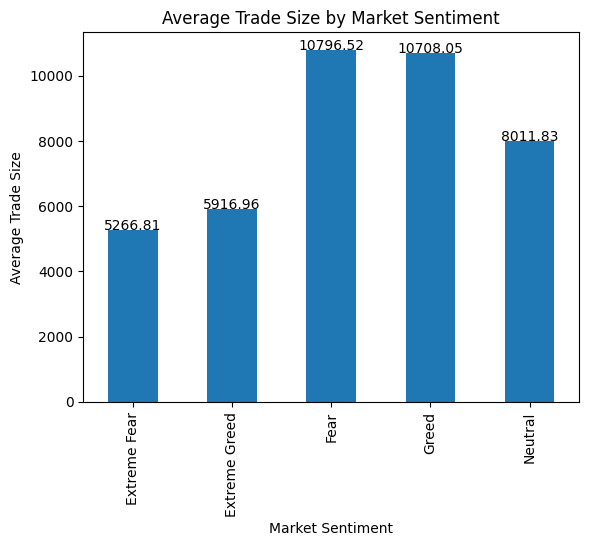

In [130]:
trade_size.plot(kind="bar")

plt.title("Average Trade Size by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Trade Size")

for i, v in enumerate(trade_size):
    plt.text(i, v, round(v,2), ha="center")

plt.show()

### Insight
The average trade size differs across market sentiment conditions. The largest average trade sizes are observed during Fear (~10,796) and Greed (~10,708), indicating that traders take larger positions during these market phases. In contrast, Extreme Fear (~5,269) and Extreme Greed (~5,916) show smaller trade sizes, suggesting more cautious trading behavior during extreme market emotions. Neutral sentiment (~8,012) shows moderate trade sizes. Overall, this indicates that traders tend to increase their trade size during regular Fear or Greed phases compared to extreme sentiment conditions.

### Frequent vs Infrequent Traders

In [131]:
trade_count = market_sentiment["Account"].value_counts()

frequent_traders = trade_count[trade_count > trade_count.median()]
infrequent_traders = trade_count[trade_count <= trade_count.median()]

print("Frequent Traders:", len(frequent_traders))
print("Infrequent Traders:", len(infrequent_traders))

Frequent Traders: 8
Infrequent Traders: 8


Traders were segmented based on trading frequency and position exposure. The analysis shows that 8 traders are classified as frequent traders and 8 as infrequent traders, indicating a balanced distribution of trading activity among accounts. Additionally, position size was used as a proxy for leverage since the dataset does not contain a direct leverage column. Trades with position size above the median were categorized as high leverage, while those below the median were considered low leverage. This segmentation helps identify differences in trading behavior and risk exposure among traders.

### High vs Low Leverage Traders

In [132]:
median_position = market_sentiment["Start Position"].median()

high_leverage = market_sentiment[market_sentiment["Start Position"] > median_position]
low_leverage = market_sentiment[market_sentiment["Start Position"] <= median_position]

print("High Leverage Trades:", len(high_leverage))
print("Low Leverage Trades:", len(low_leverage))

High Leverage Trades: 44851
Low Leverage Trades: 44852


Traders were segmented based on trading frequency and position exposure. The analysis shows that 8 traders are classified as frequent traders and 8 as infrequent traders, indicating a balanced distribution of trading activity among accounts. Additionally, position size was used as a proxy for leverage since the dataset does not contain a direct leverage column. Trades with position size above the median were categorized as high leverage, while those below the median were considered low leverage. This segmentation helps identify differences in trading behavior and risk exposure among traders.

### Consistent Winners vs Losing Traders

In [133]:
trader_pnl = market_sentiment.groupby("Account")["Closed PnL"].sum()

winning_traders = trader_pnl[trader_pnl > 0]
losing_traders = trader_pnl[trader_pnl <= 0]

print("Winning Traders:", len(winning_traders))
print("Losing Traders:", len(losing_traders))

Winning Traders: 15
Losing Traders: 1


The analysis shows that 15 traders are profitable while only 1 trader is losing, indicating that the majority of traders in the dataset generated positive overall returns. This suggests a strong concentration of profitable trading accounts, while only a small portion experienced net losses. The result may indicate effective trading strategies or favorable market conditions during the analyzed period.

## Strategic Ideas / Rule of Thumb
1. ### Trade with Market Sentiment
Traders may consider increasing trading activity during Extreme Greed and Fear conditions, as these phases show higher profitability and trading opportunities. However, during Extreme Fear, traders should remain cautious because market volatility can increase risk.

2. ### Apply Strong Risk Management
Since the analysis shows large drawdowns during certain sentiment phases (especially Greed), traders should use risk management techniques such as smaller position sizes, stop-loss orders, and controlled leverage to reduce potential losses and protect capital.

## conclusion
Based on the analysis, traders may achieve better performance during Extreme Greed market conditions, as both profitability and win rate appear higher in bullish sentiment. However, the large drawdown observed during Greed suggests that traders should manage risk carefully and avoid excessive position sizes during optimistic markets. Since trading activity increases significantly during Fear, traders and platforms should monitor market volatility and apply risk management strategies such as stop-loss orders. Additionally, maintaining balanced leverage and position sizes can help control potential losses. Overall, traders should combine market sentiment analysis with disciplined risk management to improve trading outcomes.